### **Stage3: Bivariate LISA Analysis**

In [1]:
# Imports and configuration

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from libpysal.weights import KNN
from esda.moran import Moran_Local_BV

np.random.seed(42)

# Standard LISA colours
C_HH = '#FF0000'
C_LL = '#0000FF'
C_HL = '#FF9999'
C_LH = '#9999FF'
C_NS = '#D3D3D3'

LISA_LEGEND = [
    Patch(facecolor=C_HH, label='High-High'),
    Patch(facecolor=C_LL, label='Low-Low'),
    Patch(facecolor=C_HL, label='High-Low'),
    Patch(facecolor=C_LH, label='Low-High'),
    Patch(facecolor=C_NS, label='Not Significant')
]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

In [2]:
# Load shapefile, create clean columns, validate for NaN
gdf = gpd.read_file('GLA_Master.shp')

gdf['IncRate_2020'] = gdf['IncRate'].str.replace('%', '').astype(float)
gdf['IncRate_2016'] = gdf['IncRate_1'] * 100
gdf['VDL_2016'] = gdf['VDL_Ratio1']
gdf['VDL_2020'] = gdf['VDL_Ratio2']
gdf['GreenRatio'] = gdf['PAN_GreenR']
gdf['NoGreen'] = 1 - gdf['GreenRatio']

analysis_cols = ['IncRate_2016', 'IncRate_2020', 'NO2_2016', 'NO2_2020',
                 'VDL_2016', 'VDL_2020', 'NoGreen']

print('NaN check:')
for col in analysis_cols:
    n_miss = gdf[col].isna().sum()
    if n_miss > 0:
        median_val = gdf[col].median()
        print(f'  WARNING: {col} has {n_miss} NaN(s) - filling with median ({median_val:.4f})')
        gdf[col] = gdf[col].fillna(median_val)
    else:
        print(f'  OK: {col}')

print(f'\nLoaded: {len(gdf)} data zones')
print(f'CRS: {gdf.crs}')

NaN check:
  OK: IncRate_2016
  OK: IncRate_2020
  OK: NO2_2016
  OK: NO2_2020
  OK: VDL_2016
  OK: VDL_2020
  OK: NoGreen

Loaded: 746 data zones
CRS: EPSG:27700


In [3]:
# Constructing a spatial weight matrix

w = KNN.from_dataframe(gdf, k=8)
w.transform = 'r'

print(f'Spatial weights: K-Nearest Neighbours (k=8)')
print(f'Connected components: {w.n_components}')
print(f'Number of observations: {w.n}')

Spatial weights: K-Nearest Neighbours (k=8)
Connected components: 1
Number of observations: 746


In [4]:
# Bivariate LISA function

def bivariate_lisa(gdf, x, y, w, title, ax, permutations=9999, alpha=0.05, fdr_correct=True):
    '''Bivariate LISA: tests whether x_i is associated with the spatial lag of y.

    HH = high x surrounded by high y (compounded disadvantage)
    LL = low x surrounded by low y (compounded advantage)
    HL = high x surrounded by low y (spatial mismatch)
    LH = low x surrounded by high y (spatial mismatch)
    '''
    # Standardise both variables
    zx = (x.values - x.values.mean()) / x.values.std()
    zy = (y.values - y.values.mean()) / y.values.std()

    # PySAL bivariate local Moran
    lisa_bv = Moran_Local_BV(zx, zy, w, permutations=permutations)

    # Significance threshold
    if fdr_correct:
        n = len(lisa_bv.p_sim)
        sorted_p = np.sort(lisa_bv.p_sim)
        bh_threshold = np.arange(1, n + 1) / n * alpha
        valid = sorted_p <= bh_threshold
        cutoff = sorted_p[np.where(valid)[0][-1]] if valid.any() else 0.0
        sig = lisa_bv.p_sim <= cutoff
        method = f'FDR a={alpha}'
    else:
        sig = lisa_bv.p_sim < alpha
        method = f'a={alpha}'

    # Quadrants: 1=HH, 2=LH, 3=LL, 4=HL, 0=not significant
    labels = lisa_bv.q.copy()
    labels[~sig] = 0

    color_map = {0: C_NS, 1: C_HH, 2: C_LH, 3: C_LL, 4: C_HL}
    colors = [color_map[l] for l in labels]

    gdf.plot(ax=ax, color=colors, edgecolor='black', linewidth=0.2)
    ax.set_title(f'{title}\n({method}, {sig.sum()} sig.)')
    ax.axis('off')

    counts = {
        'HH': int((labels == 1).sum()),
        'LL': int((labels == 3).sum()),
        'LH': int((labels == 2).sum()),
        'HL': int((labels == 4).sum()),
        'NS': int((labels == 0).sum())
    }

    # Global bivariate Moran's I
    lag_zy = w.sparse @ zy
    bi_global = np.sum(zx * lag_zy) / len(zx)

    return bi_global, counts, lisa_bv.p_sim

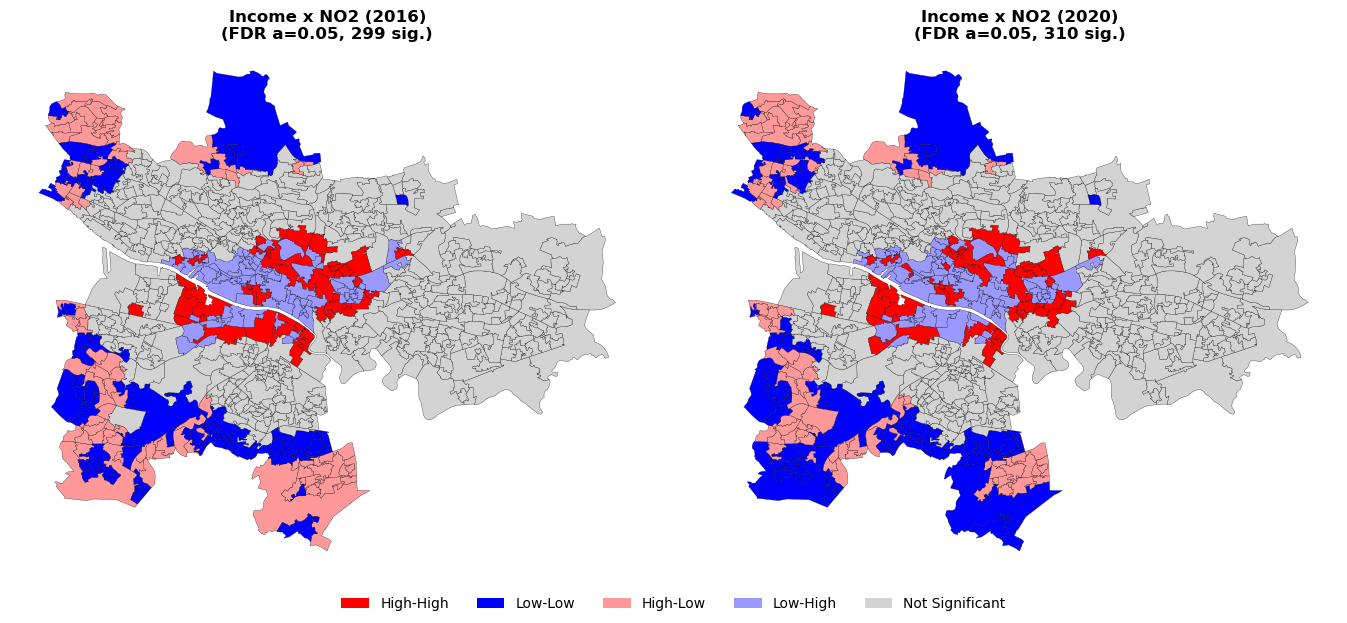

Bivariate Moran's I: 2016 = -0.1138, 2020 = -0.1347
2016 clusters: {'HH': 51, 'LL': 79, 'LH': 78, 'HL': 91, 'NS': 447}
2020 clusters: {'HH': 54, 'LL': 82, 'LH': 79, 'HL': 95, 'NS': 436}


In [5]:
# Income × NO2（2016 and 2020）

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bi_no2_16, counts_no2_16, _ = bivariate_lisa(
    gdf, gdf['IncRate_2016'], gdf['NO2_2016'], w,
    'Income x NO2 (2016)', axes[0])
bi_no2_20, counts_no2_20, _ = bivariate_lisa(
    gdf, gdf['IncRate_2020'], gdf['NO2_2020'], w,
    'Income x NO2 (2020)', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"Bivariate Moran's I: 2016 = {bi_no2_16:.4f}, 2020 = {bi_no2_20:.4f}")
print(f'2016 clusters: {counts_no2_16}')
print(f'2020 clusters: {counts_no2_20}')

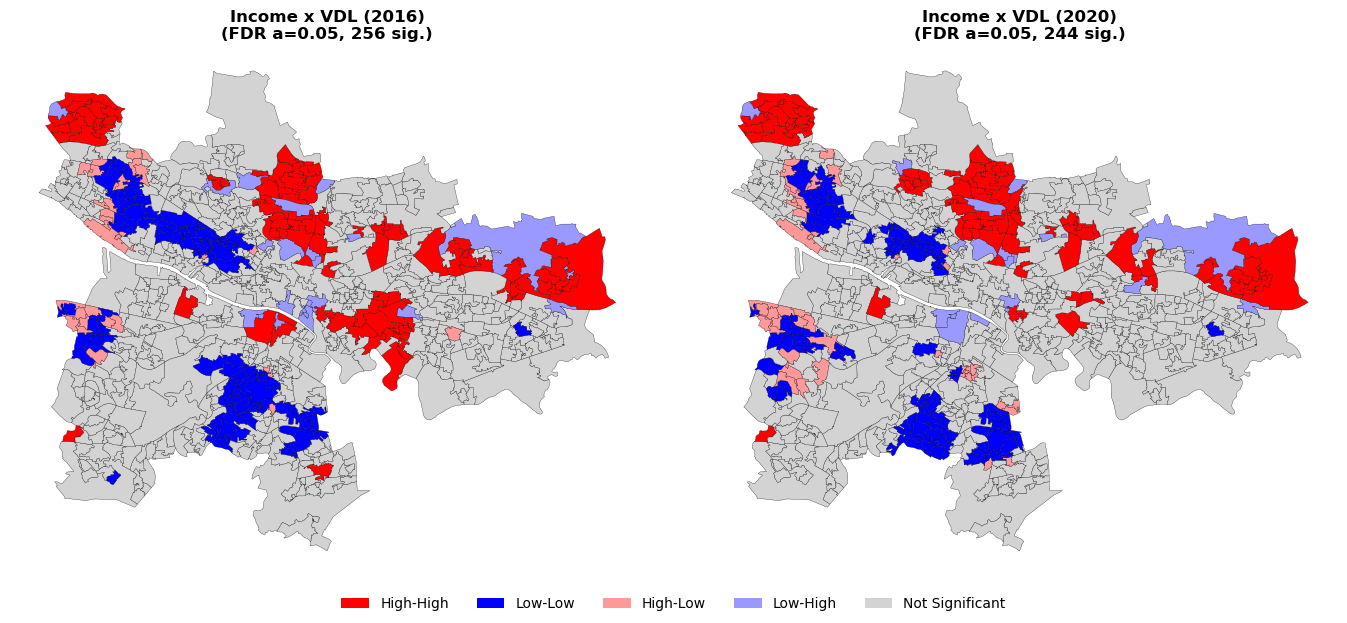

Bivariate Moran's I: 2016 = 0.3110, 2020 = 0.2809
2016 clusters: {'HH': 96, 'LL': 107, 'LH': 22, 'HL': 31, 'NS': 490}
2020 clusters: {'HH': 79, 'LL': 103, 'LH': 18, 'HL': 44, 'NS': 502}


In [6]:
# Income × VDL（2016 and 2020）

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bi_vdl_16, counts_vdl_16, _ = bivariate_lisa(
    gdf, gdf['IncRate_2016'], gdf['VDL_2016'], w,
    'Income x VDL (2016)', axes[0])
bi_vdl_20, counts_vdl_20, _ = bivariate_lisa(
    gdf, gdf['IncRate_2020'], gdf['VDL_2020'], w,
    'Income x VDL (2020)', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"Bivariate Moran's I: 2016 = {bi_vdl_16:.4f}, 2020 = {bi_vdl_20:.4f}")
print(f'2016 clusters: {counts_vdl_16}')
print(f'2020 clusters: {counts_vdl_20}')

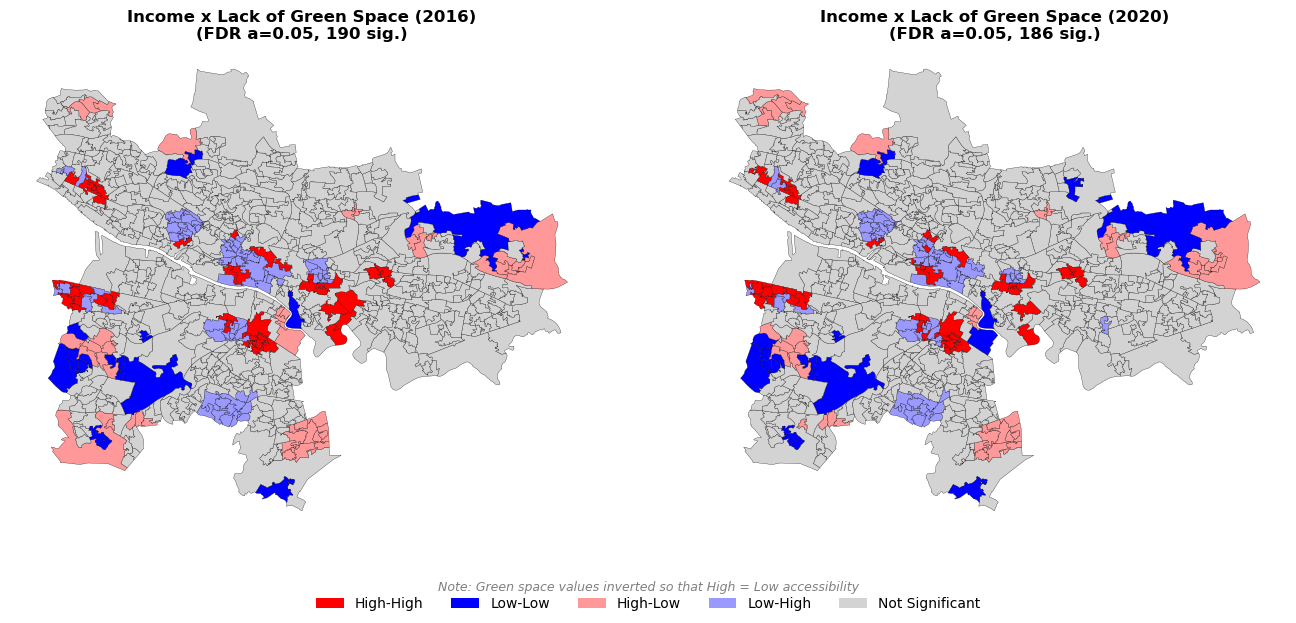

Bivariate Moran's I: 2016 = -0.1435, 2020 = -0.1599
2016 clusters: {'HH': 49, 'LL': 20, 'LH': 74, 'HL': 47, 'NS': 556}
2020 clusters: {'HH': 50, 'LL': 21, 'LH': 67, 'HL': 48, 'NS': 560}


In [7]:
# Income × Lack of Green Space（2016 only, green space is static）

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bi_green_16, counts_green_16, _ = bivariate_lisa(
    gdf, gdf['IncRate_2016'], gdf['NoGreen'], w,
    'Income x Lack of Green Space (2016)', axes[0])
bi_green_20, counts_green_20, _ = bivariate_lisa(
    gdf, gdf['IncRate_2020'], gdf['NoGreen'], w,
    'Income x Lack of Green Space (2020)', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
fig.text(0.5, 0.05, 'Note: Green space values inverted so that High = Low accessibility',
         ha='center', fontsize=9, style='italic', color='grey')
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

print(f"Bivariate Moran's I: 2016 = {bi_green_16:.4f}, 2020 = {bi_green_20:.4f}")
print(f'2016 clusters: {counts_green_16}')
print(f'2020 clusters: {counts_green_20}')

In [8]:
# Summary of Bivariate LISA results

print('=' * 78)
print('BIVARIATE LISA SUMMARY')
print('=' * 78)
print()
print('HH = High income deprivation surrounded by poor environment')
print('LL = Low income deprivation surrounded by good environment')
print('HL/LH = Spatial mismatch')
print()
print(f'{"Pair":<35} {"Year":<6} {"Bi-I":>8} {"HH":>6} {"LL":>6} {"HL":>6} {"LH":>6} {"NS":>6}')
print('-' * 78)

rows = [
    ('Income x NO2',              '2016', bi_no2_16,    counts_no2_16),
    ('Income x NO2',              '2020', bi_no2_20,    counts_no2_20),
    ('Income x VDL',              '2016', bi_vdl_16,    counts_vdl_16),
    ('Income x VDL',              '2020', bi_vdl_20,    counts_vdl_20),
    ('Income x Lack of Green',    '2016', bi_green_16,  counts_green_16),
    ('Income x Lack of Green',    '2020', bi_green_20,  counts_green_20),
]

for pair, year, bi_i, c in rows:
    print(f'{pair:<35} {year:<6} {bi_i:>8.4f} {c["HH"]:>6} {c["LL"]:>6} {c["HL"]:>6} {c["LH"]:>6} {c["NS"]:>6}')

print()
print('Permutations: 9999 | Significance: FDR-corrected p < 0.05')

BIVARIATE LISA SUMMARY

HH = High income deprivation surrounded by poor environment
LL = Low income deprivation surrounded by good environment
HL/LH = Spatial mismatch

Pair                                Year       Bi-I     HH     LL     HL     LH     NS
------------------------------------------------------------------------------
Income x NO2                        2016    -0.1138     51     79     91     78    447
Income x NO2                        2020    -0.1347     54     82     95     79    436
Income x VDL                        2016     0.3110     96    107     31     22    490
Income x VDL                        2020     0.2809     79    103     44     18    502
Income x Lack of Green              2016    -0.1435     49     20     47     74    556
Income x Lack of Green              2020    -0.1599     50     21     48     67    560

Permutations: 9999 | Significance: FDR-corrected p < 0.05


In [1]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'html', 'Bivariate_LISA.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'Bivariate_LISA.ipynb'], returncode=0)